In [ ]:
#  — Imports

import numpy as np
import matplotlib.pyplot as plt

from datasets import load_dataset

In [ ]:
# — Load Iris Dataset 

iris = load_dataset("scikit-learn/iris")


In [21]:
# Inspect Dataset Structure

iris = load_dataset("scikit-learn/iris")

data = iris["train"]

print(data)

print("\nColumn Names:\n")

print(data.column_names)

print("\nFirst Sample:\n")

print(data[0])

Dataset({
    features: ['Id', 'SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm', 'Species'],
    num_rows: 150
})

Column Names:

['Id', 'SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm', 'Species']

First Sample:

{'Id': 1, 'SepalLengthCm': 5.1, 'SepalWidthCm': 3.5, 'PetalLengthCm': 1.4, 'PetalWidthCm': 0.2, 'Species': 'Iris-setosa'}


In [32]:
# corrected Load Iris Dataset

iris = load_dataset("scikit-learn/iris")

data = iris["train"]

X = np.column_stack([
    data["SepalLengthCm"],
    data["SepalWidthCm"],
    data["PetalLengthCm"],
    data["PetalWidthCm"]
])

species_names = np.array(data["Species"])

# Convert species strings into integer labels

unique_species = np.unique(species_names)

species_to_id = {
    species: idx
    for idx, species in enumerate(unique_species)
}

y = np.array([
    species_to_id[s]
    for s in species_names
])
# Feature Selection

X_vis = X[:, :2]

print(X_vis.shape)

print("Dataset Shape:", X.shape)

print("Labels Shape:", y.shape)

print("\nUnique Species:")

print(unique_species)

(150, 2)
Dataset Shape: (150, 4)
Labels Shape: (150,)

Unique Species:
['Iris-setosa' 'Iris-versicolor' 'Iris-virginica']


In [ ]:
#  Euclidean Distance Function

def euclidean_distance(a, b):

    return np.sqrt(np.sum((a - b) ** 2))

In [ ]:
#  Initialize Centroids

def initialize_centroids(X, k):

    n_samples = X.shape[0]

    indices = np.random.choice(
        n_samples,
        size=k,
        replace=False
    )

    centroids = X[indices]

    return centroids

In [ ]:
#  Assignment Step

def assign_clusters(X, centroids):

    labels = []

    for point in X:

        distances = []

        for centroid in centroids:

            d = euclidean_distance(point, centroid)

            distances.append(d)

        cluster_id = np.argmin(distances)

        labels.append(cluster_id)

    return np.array(labels)

In [ ]:
#  Centroid Update Step

def update_centroids(X, labels, k):

    n_features = X.shape[1]

    new_centroids = np.zeros((k, n_features))

    for cluster_id in range(k):

        cluster_points = X[labels == cluster_id]

        if len(cluster_points) > 0:

            centroid = np.mean(cluster_points, axis=0)

            new_centroids[cluster_id] = centroid

    return new_centroids

In [ ]:
#  Compute Total Discrepancy Loss

def compute_loss(X, labels, centroids):

    total_loss = 0.0

    for i in range(len(X)):

        centroid = centroids[labels[i]]

        loss = np.sum((X[i] - centroid) ** 2)

        total_loss += loss

    return total_loss

In [ ]:
# Full K-Means Algorithm

def kmeans(
    X,
    k,
    max_iterations=100,
    tolerance=1e-4
):

    centroids = initialize_centroids(X, k)

    for iteration in range(max_iterations):

        labels = assign_clusters(X, centroids)

        new_centroids = update_centroids(
            X,
            labels,
            k
        )

        centroid_shift = np.linalg.norm(
            new_centroids - centroids
        )

        centroids = new_centroids

        if centroid_shift < tolerance:

            print(f"Converged after {iteration+1} iterations")

            break

    final_loss = compute_loss(
        X,
        labels,
        centroids
    )

    return labels, centroids, final_loss

In [39]:
#  Run Experiments

k_values = [2, 3, 4, 5]

results = {}

losses = []

for k in k_values:

    labels, centroids, loss = kmeans(X_vis, k)

    results[k] = {
        "labels": labels,
        "centroids": centroids,
        "loss": loss
    }

    losses.append(loss)

    print(f"\nk = {k}")

    print(f"Total Discrepancy Loss = {loss:.4f}")

Converged after 2 iterations

k = 2
Total Discrepancy Loss = 57.9965
Converged after 9 iterations

k = 3
Total Discrepancy Loss = 37.1412
Converged after 8 iterations

k = 4
Total Discrepancy Loss = 27.9587
Converged after 9 iterations

k = 5
Total Discrepancy Loss = 21.1246


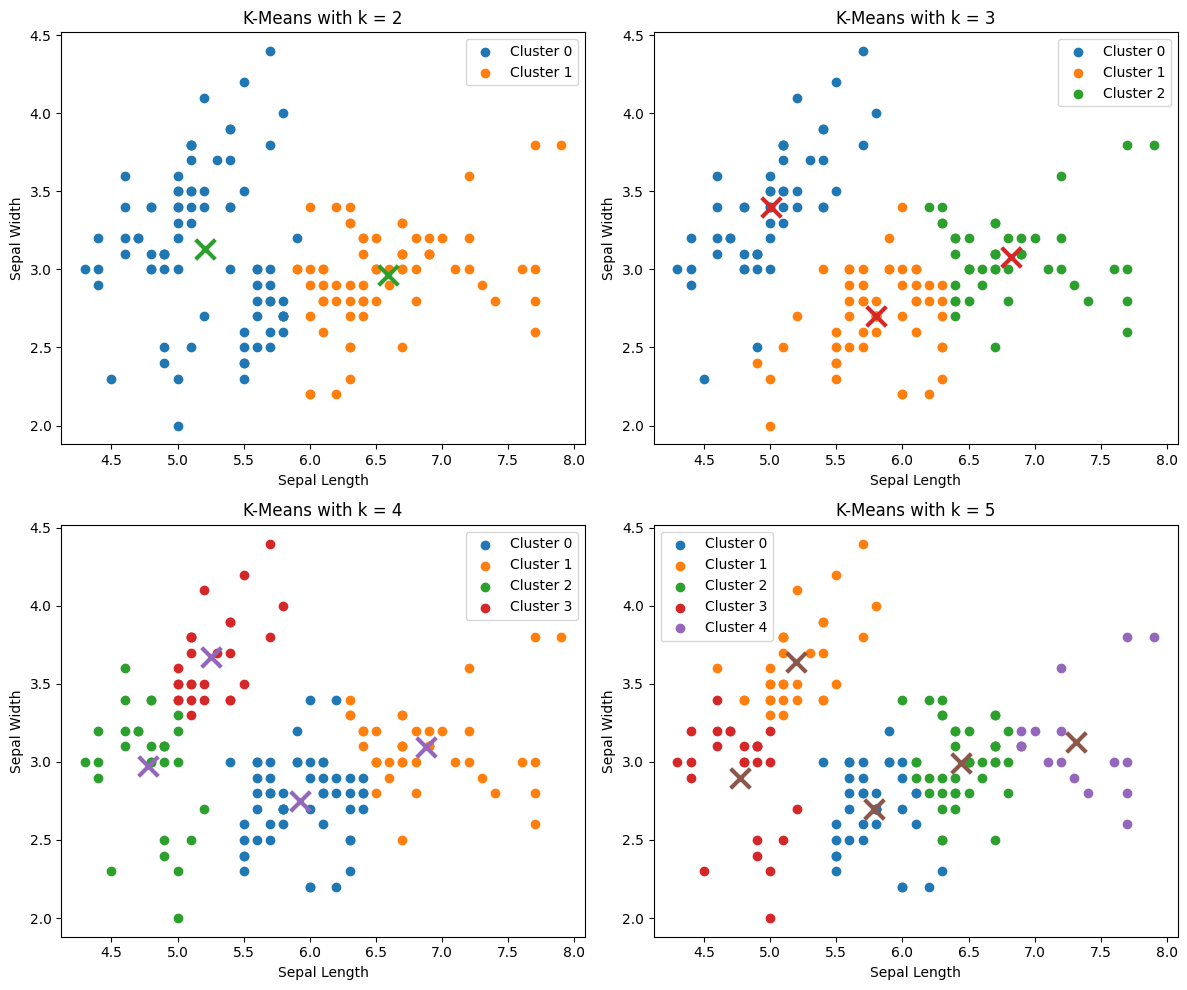

In [40]:
# Plot Clusters

fig, axes = plt.subplots(
    2,
    2,
    figsize=(12,10)
)

axes = axes.flatten()

for idx, k in enumerate(k_values):

    labels = results[k]["labels"]

    centroids = results[k]["centroids"]

    ax = axes[idx]

    for cluster_id in range(k):

        cluster_points = X_vis[
            labels == cluster_id
        ]

        ax.scatter(
            cluster_points[:,0],
            cluster_points[:,1],
            label=f"Cluster {cluster_id}"
        )

    ax.scatter(
        centroids[:,0],
        centroids[:,1],
        marker='x',
        s=200,
        linewidths=3
    )

    ax.set_title(f"K-Means with k = {k}")

    ax.set_xlabel("Sepal Length")

    ax.set_ylabel("Sepal Width")

    ax.legend()

plt.tight_layout()

plt.show()